# Prediction Curves for the 18th of February 2022

In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import os

### Curve Real Data

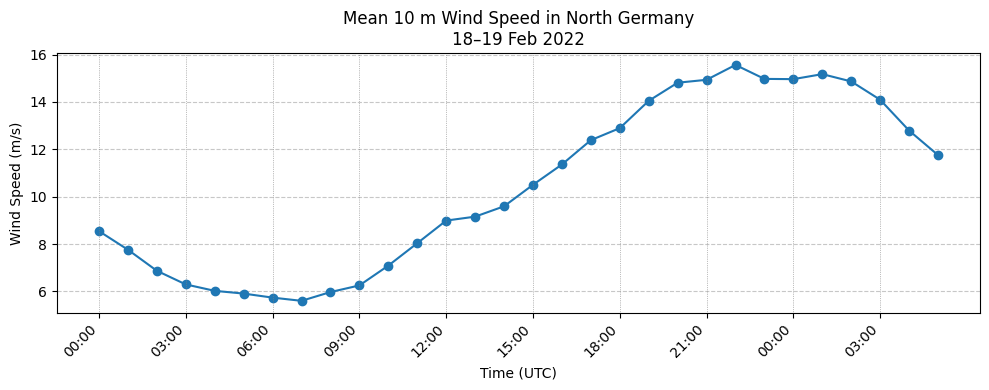

In [ ]:
# Load dataset
ds = xr.open_dataset("../data/north_germany_wind_20220218_19_1res.nc")

# Compute wind speed magnitude
u = ds['u10']
v = ds['v10']
wind_speed = np.sqrt(u**2 + v**2)

# Compute spatial mean
mean_wind = wind_speed.mean(dim=["latitude", "longitude"])

# 1) Rename the coordinate so we can slice by 'time'
mean_wind = mean_wind.rename({'valid_time': 'time'})

# 2) Slice everything up through 05:00 on Feb 19
mean_wind = mean_wind.sel(time=slice(None, "2022-02-19T05:00"))

# Plot
fig, ax = plt.subplots(figsize=(10, 4))
mean_wind.plot(ax=ax, marker='o', linestyle='-')

ax.set_title("Mean 10 m Wind Speed in North Germany\n18–19 Feb 2022")
ax.set_ylabel("Wind Speed (m/s)")
ax.set_xlabel("Time (UTC)")

# 3) Add a vertical grid & tick every 3 hours
# Find all timestamps at hours divisible by 3
ticks = [t for t in mean_wind['time'].values
         if int(str(t).split("T")[1][:2]) % 3 == 0]

ax.set_xticks(ticks)
ax.set_xticklabels([str(t).split("T")[1][:5] for t in ticks], rotation=45, ha="right")

# Light dotted grid lines at those ticks
for t in ticks:
    ax.axvline(t, color='gray', linestyle=':', linewidth=0.5)

# You still get horizontal grid for y
ax.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

### Prediction Curve

Graph with 3 lines: the observed data, the predicted data (1 step), the predicted data (longrange)

/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_71724/3681833229.py:27: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_71724/3681833229.py:27: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_71724/3681833229.py:27: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_71724/36818

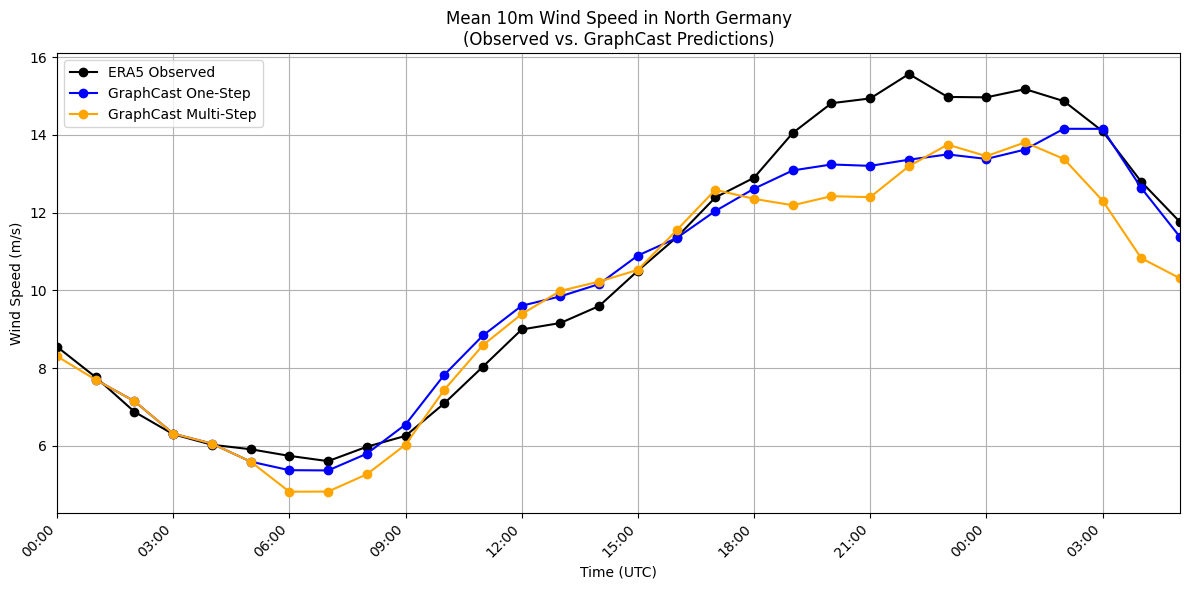

In [ ]:
# ---------- Real Data ----------
ds_real = xr.open_dataset("../data/north_germany_wind_20220218_19_1res.nc")
u = ds_real['u10']
v = ds_real['v10']
wind_speed = np.sqrt(u**2 + v**2)
mean_wind_real = wind_speed.mean(dim=["latitude", "longitude"])
real_series = mean_wind_real.to_series()

# keep only up through 05:00 on Feb 19
real_series = real_series.loc[: "2022-02-19 05:00"]

# ---------- Single-Step Prediction (extended to Feb 19 06:00) ----------
base_dir_single = "../data/prediction_curve/predictions_curve_one_step"

# first Feb 18 (01:00–23:00), then Feb 19 (00:00–06:00)
times_18 = [f"{h:02d}00" for h in range(1, 24)]
times_19 = [f"{h:02d}00" for h in range(0, 7)]
all_data_single = []

# helper to collect one-step forecasts for a given day
def collect_one_step(day_str, time_list):
    for t in time_list:
        fn = f"curve_prediction_one_step_{day_str}_{t}.nc"
        path = os.path.join(base_dir_single, fn)
        if not os.path.exists(path):
            continue
        ds = xr.open_dataset(path)
        # assign the correct forecast timestamp
        dt = np.datetime64(f"{day_str}T{t[:2]}:00")
        ds = ds.drop_vars("time").assign_coords(time=("time", [dt]))

        sub = ds.sel(lat=slice(55.0, 53.0), lon=slice(7.5, 10.5))
        u10 = sub["10m_u_component_of_wind"]
        v10 = sub["10m_v_component_of_wind"]
        ws = np.sqrt(u10**2 + v10**2)
        spatial_mean = ws.mean(dim=["lat", "lon"]).isel(batch=0, drop=True)
        clean = spatial_mean.drop_vars(["number", "expver"], errors="ignore")
        all_data_single.append(clean)

# collect for Feb 18 and then Feb 19
collect_one_step("2022-02-18", times_18)
collect_one_step("2022-02-19", times_19)

combined_single_ext = xr.concat(all_data_single, dim="time").sortby("time")
single_series_ext = combined_single_ext.to_series()

# ---------- Multi-Step Prediction (unchanged) ----------
base_dir_multi = "../data/prediction_curve/predictions_curve_7_steps"
start_times = ["0000", "0100", "0200", "0300", "0400", "0500"]
all_data_multi = []

for start in start_times:
    path = f"{base_dir_multi}/curve_prediction_7_steps_2022-02-18_start_{start}.nc"
    ds = xr.open_dataset(path)
    forecast_times = [
        np.datetime64(f"2022-02-18T{start[:2]}:{start[2:]}") + np.timedelta64(6 * i, "h")
        for i in range(ds.sizes["time"])
    ]
    ds = ds.assign_coords(time=("time", forecast_times))
    sub = ds.sel(lat=slice(55.0, 53.0), lon=slice(7.5, 10.5))
    u10 = sub["10m_u_component_of_wind"]
    v10 = sub["10m_v_component_of_wind"]
    ws = np.sqrt(u10**2 + v10**2)
    spatial_mean = ws.mean(dim=["lat", "lon"]).isel(batch=0, drop=True)
    clean = spatial_mean.drop_vars(["number", "expver"], errors="ignore")
    all_data_multi.append(clean)

combined_multi = xr.concat(all_data_multi, dim="time").sortby("time")
multi_series = combined_multi.to_series()

# ---------- Plot Combined ----------
plt.figure(figsize=(12, 6))
real_series.plot(marker='o', label="ERA5 Observed", color='black')
single_series_ext.plot(marker='o', label="GraphCast One-Step", color='blue')
multi_series.plot(marker='o', label="GraphCast Multi-Step", color='orange')

plt.title("Mean 10m Wind Speed in North Germany\n(Observed vs. GraphCast Predictions)")
plt.xlabel("Time (UTC)")
plt.ylabel("Wind Speed (m/s)")
plt.grid(True)
plt.legend()

ticks = real_series.index[::3]
plt.xticks(ticks, [t.strftime("%H:%M") for t in ticks], rotation=45, ha="right")

plt.tight_layout()
plt.show()

